# 8. Antialiasing

Perfect. You’re at the **anti-aliasing** step of *Ray Tracing in One Weekend*.
I’ll map the C++ idea into your Python code with:

1. **What changes**
2. **Why we change it**
3. **Math formulas**
4. **Purpose of each step**
5. **Markdown tables**
6. **Final Python code**

---

# 1. Why aliasing happens

Right now you shoot **one ray per pixel**.

That means:

$$
Color(i,j)=f(x_c,y_c)
$$

where:

* $(x_c,y_c)$ = pixel center
* $f$ = light/color function

Problem:

If the object edge cuts through the pixel:

* center may hit object
* or miss object

So color becomes abrupt.

That creates jagged edges.

---

# 2. Real world solution

A pixel is actually an **area**, not a point.

Real color should be:

$$
C = \frac{1}{A}\int_A f(x,y),dA
$$

Where:

* $A$ = pixel area
* $f(x,y)$ = light at point $(x,y)$

This is continuous integration.

But exact integration is expensive.

So we approximate:

$$
C \approx \frac{1}{N}\sum_{k=1}^{N} f(x_k,y_k)
$$

This is **Monte Carlo integration**.

---

# 3. Old vs New

| Method        | Formula                    | Meaning             |
| ------------- | -------------------------- | ------------------- |
| Single sample | $C=f(x_c,y_c)$             | one point only      |
| Multi sample  | $C=\frac1N\sum f(x_k,y_k)$ | average many points |

---

# 4. Sampling inside pixel

Instead of center:

Old:

$$
(x,y)=(i,j)
$$

New:

$$
(x,y)=(i+\delta_x,j+\delta_y)
$$

Where:

$$
-0.5 \le \delta_x < 0.5
$$

$$
-0.5 \le \delta_y < 0.5
$$

This makes random positions inside pixel.

---

# 5. What to change

---

## Step A: Add random module

```python
import random
```

Purpose:

| Thing            | Why                  |
| ---------------- | -------------------- |
| random.uniform() | random pixel offsets |

---

---

## Step B: Add samples_per_pixel

Inside `__init__`

```python
self.samples_per_pixel = 100
```

Purpose:

| Variable          | Meaning                  |
| ----------------- | ------------------------ |
| samples_per_pixel | number of rays per pixel |

Formula:

$$
Scale=\frac1N
$$

---

---

## Step C: Random sample square

Add:

```python
def sample_square(self):
    return Vec3(
        random.random() - 0.5,
        random.random() - 0.5,
        0
    )
```

---

### Formula:

Random number:

$$
r\in[0,1)
$$

Shift to center:

$$
r-0.5 \in [-0.5,0.5)
$$

Purpose:

| Part            | Meaning                  |
| --------------- | ------------------------ |
| random.random() | random in $[0,1)$        |
| -0.5            | move around pixel center |

---

---

## Step D: Modify get_ray()

Old:

```python
pixel_center = (
    self.pixel00_loc
    + self.pixel_delta_u * i
    + self.pixel_delta_v * j
)
```

New:

```python
offset = self.sample_square()

pixel_sample = (
    self.pixel00_loc
    + self.pixel_delta_u * (i + offset.x)
    + self.pixel_delta_v * (j + offset.y)
)
```

---

### Formula:

Pixel point:

$$
P=P_{00}+(i+\delta_x)\Delta_u+(j+\delta_y)\Delta_v
$$

Where:

* $P_{00}$ = first pixel
* $\Delta_u$ = horizontal pixel step
* $\Delta_v$ = vertical pixel step

Ray:

$$
R(t)=O+t(P-O)
$$

Purpose:

| Step            | Meaning             |
| --------------- | ------------------- |
| random offset   | random sub-pixel    |
| build point     | sample inside pixel |
| subtract center | ray direction       |

---

---

## Step E: Average samples

Old render:

```python
r = self.get_ray(i, j)
pixel_color = self.ray_color(r, world)
```

New:

```python
pixel_color = Vec3(0, 0, 0)

for sample in range(self.samples_per_pixel):
    r = self.get_ray(i, j)
    pixel_color += self.ray_color(r, world)

pixel_color /= self.samples_per_pixel
```

---

Formula:

Accumulation:

$$
C_{sum}=\sum_{k=1}^{N} C_k
$$

Average:

$$
C=\frac{C_{sum}}{N}
$$

Purpose:

| Step       | Why             |
| ---------- | --------------- |
| accumulate | gather samples  |
| divide     | compute average |

---

# Final camera code

Here is the **full `camera.py`** rewritten to match the C++ anti-aliasing method exactly, using your current structure.

It includes:

* `samples_per_pixel`
* `random subpixel sampling`
* `pixel averaging`
* `interval clamp`
* proper comments
* same logic as the book

---

## Full `camera.py`

```python
from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.hit_record import HitRecord
from util.interval import Interval
from util.image_viewer import image_viewer
from tqdm import tqdm

import random

INFINITY = float("inf")


# -----------------------------------
# RANDOM UTILITIES
# -----------------------------------

def random_double():
    """
    Returns a random real in [0,1)

    Formula:
    r ∈ [0,1)
    """
    return random.random()


def random_double_range(min_val, max_val):
    """
    Returns random real in [min,max)

    Formula:
    x = min + (max-min)r
    where r ∈ [0,1)
    """
    return min_val + (max_val - min_val) * random_double()


class Camera:
    """
    Camera class handles:

    1. Image plane setup
    2. Ray generation
    3. Anti-aliasing
    4. Rendering
    """

    # -----------------------------------
    # USER SETTINGS
    # -----------------------------------
    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100   # Anti-aliasing samples

    # -----------------------------------
    # MAIN RENDER FUNCTION
    # -----------------------------------
    def render(self, world):
        """
        Render the whole scene.

        Anti-aliasing:
        For each pixel:
        C = (1/N) * Σ C_i
        """

        # Prepare camera
        self.initialize()

        with open("output.ppm", "w") as f:

            # Write PPM header
            f.write(
                f"P3\n{self.image_width} {self.image_height}\n255\n"
            )

            # Scan image rows
            for j in tqdm(range(self.image_height), desc="Rendering"):

                # Scan columns
                for i in range(self.image_width):

                    # Accumulate all sample colors
                    pixel_color = Vec3(0, 0, 0)

                    # Multi-sampling loop
                    for sample in range(self.samples_per_pixel):

                        # Generate random ray inside pixel
                        r = self.get_ray(i, j)

                        # Add sample color
                        pixel_color += self.ray_color(r, world)

                    # Average all samples
                    pixel_color = (
                        self.pixel_samples_scale * pixel_color
                    )

                    # Clamp color values to safe range
                    intensity = Interval(0.000, 0.999)

                    ir = int(
                        256 * intensity.clamp(pixel_color.x)
                    )
                    ig = int(
                        256 * intensity.clamp(pixel_color.y)
                    )
                    ib = int(
                        256 * intensity.clamp(pixel_color.z)
                    )

                    # Write final pixel
                    f.write(f"{ir} {ig} {ib}\n")

        print("Done!")

    # -----------------------------------
    # CAMERA SETUP
    # -----------------------------------
    def initialize(self):
        """
        Compute camera geometry.

        Also precompute sample scaling:
        scale = 1 / samples_per_pixel
        """

        # Compute image height
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        # Scale factor for averaging samples
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # Camera center
        self.center = Vec3(0, 0, 0)

        # Viewport settings
        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # Horizontal viewport edge
        viewport_u = Vec3(viewport_width, 0, 0)

        # Vertical viewport edge
        viewport_v = Vec3(0, -viewport_height, 0)

        # Pixel step vectors
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # Top-left viewport corner
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # Center of first pixel
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    # -----------------------------------
    # RANDOM SUBPIXEL SAMPLE
    # -----------------------------------
    def sample_square(self):
        """
        Returns random point inside unit square.

        Range:
        [-0.5,+0.5)

        Formula:
        offset = random() - 0.5
        """

        return Vec3(
            random_double() - 0.5,
            random_double() - 0.5,
            0
        )

    # -----------------------------------
    # BUILD CAMERA RAY
    # -----------------------------------
    def get_ray(self, i, j):
        """
        Create ray through random point inside pixel.

        Formula:
        P = P00 + (i+dx)Δu + (j+dy)Δv

        where:
        dx,dy ∈ [-0.5,+0.5)
        """

        # Random offset inside pixel
        offset = self.sample_square()

        # Random sampled pixel location
        pixel_sample = (
            self.pixel00_loc
            + self.pixel_delta_u * (i + offset.x)
            + self.pixel_delta_v * (j + offset.y)
        )

        # Ray direction
        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # RAY COLOR
    # -----------------------------------
    def ray_color(self, r, world):
        """
        Returns ray color.

        If hit:
        visualize surface normal

        Else:
        sky gradient
        """

        rec = HitRecord()

        # Hit object
        if world.hit(r, Interval(0.001, INFINITY), rec):

            # Convert normal from [-1,1] → [0,1]
            return 0.5 * (rec.normal + Vec3(1, 1, 1))

        # Background gradient
        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return white * (1 - t) + blue * t

    # -----------------------------------
    # SHOW IMAGE
    # -----------------------------------
    def show(self):
        """
        Display output image
        """
        return image_viewer("output.ppm")
```

---

## Anti-aliasing math used

Single sample:

$$
C=f(x,y)
$$

Multi sample:

$$
C=\frac{1}{N}\sum_{k=1}^{N} C_k
$$

Subpixel sample:

$$
P=P_{00}+(i+\delta_x)\Delta_u+(j+\delta_y)\Delta_v
$$

Random offsets:

$$
\delta_x,\delta_y \in [-0.5,0.5)
$$

This is the exact method from the book.


---

# Visual idea

Single sample:

```text
+-------+
|   •   |
+-------+
```

One ray only.

---

Multi sample:

```text
+-------+
| •  •  |
|   •   |
| •   • |
+-------+
```

Many rays.

Average them.

---

Result:

$$
\text{More samples} \Rightarrow \text{less jaggies}
$$

but:

$$
\text{Render time} \propto N
$$

More samples = slower render.


## Old

```python

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.hit_record import HitRecord
from util.interval import Interval
from util.image_viewer import image_viewer
from tqdm import tqdm

import math

INFINITY = float("inf")


class Camera:
    """
    Camera class handles:
    1. Building rays
    2. Rendering image
    """

    # -----------------------------------
    # PUBLIC VARIABLES
    # User can modify these directly
    # -----------------------------------
    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400

    # -----------------------------------
    # MAIN RENDER FUNCTION
    # -----------------------------------
    def render(self, world):
      
        # Auto initialize before rendering
        self.initialize()

        with open("output.ppm", "w") as f:

            # PPM Header
            f.write(f"P3\n{self.image_width} {self.image_height}\n255\n")

            # Scan every pixel
            for j in tqdm(range(self.image_height), desc="Rendering"):
                for i in range(self.image_width):

                    # Get ray for current pixel
                    r = self.get_ray(i, j)

                    # Compute color
                    pixel_color = self.ray_color(r, world)

                    ir = int(255.999 * pixel_color.x)
                    ig = int(255.999 * pixel_color.y)
                    ib = int(255.999 * pixel_color.z)

                    f.write(f"{ir} {ig} {ib}\n")

        print("Done!")
        pass

    # -----------------------------------
    # INITIALIZATION
    # -----------------------------------
    def initialize(self):

        # Compute image height
        self.image_height = int(self.image_width / self.aspect_ratio)

        if self.image_height < 1:
            self.image_height = 1

        # Camera center
        self.center = Vec3(0, 0, 0)

        # Viewport setup
        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # Horizontal vector
        viewport_u = Vec3(viewport_width, 0, 0)

        # Vertical vector
        viewport_v = Vec3(0, -viewport_height, 0)

        # Pixel size
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # Top-left viewport corner
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (self.pixel_delta_u + self.pixel_delta_v)
        )

    # -----------------------------------
    # BUILD RAY FOR A PIXEL
    # -----------------------------------
    def get_ray(self, i, j):

        pixel_center = (
            self.pixel00_loc
            + self.pixel_delta_u * i
            + self.pixel_delta_v * j
        )

        ray_direction = pixel_center - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # RAY COLOR LOGIC
    # -----------------------------------
    def ray_color(self, r, world):

        rec = HitRecord()

        if world.hit(r, Interval(0.001, INFINITY), rec):
            return 0.5 * (rec.normal + Vec3(1, 1, 1))

        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return white * (1 - t) + blue * t
    
    def show(self):
        a = image_viewer("output.ppm")
        return a
```
    


## Camera with Antialasing


In [2]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [7]:
from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.hit_record import HitRecord
from util.interval import Interval
from util.image_viewer import image_viewer
from util.utility import random_double, random_double_range, INFINITY
from tqdm import tqdm



class Camera:
    """
    Camera class handles:

    1. Image plane setup
    2. Ray generation
    3. Anti-aliasing
    4. Rendering
    """

    # -----------------------------------
    # USER SETTINGS
    # -----------------------------------
    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100   # Anti-aliasing samples

    # -----------------------------------
    # MAIN RENDER FUNCTION
    # -----------------------------------
    def render(self, world):
        """
        Render the whole scene.

        Anti-aliasing:
        For each pixel:
        C = (1/N) * Σ C_i
        """

        # Prepare camera
        self.initialize()

        with open("output.ppm", "w") as f:

            # Write PPM header
            f.write(
                f"P3\n{self.image_width} {self.image_height}\n255\n"
            )

            # Scan image rows
            for j in tqdm(range(self.image_height), desc="Rendering"):

                # Scan columns
                for i in range(self.image_width):

                    # Accumulate all sample colors
                    pixel_color = Vec3(0, 0, 0)

                    # Multi-sampling loop
                    for sample in range(self.samples_per_pixel):

                        # Generate random ray inside pixel
                        r = self.get_ray(i, j)

                        # Add sample color
                        pixel_color += self.ray_color(r, world)

                    # Average all samples
                    pixel_color = (
                        self.pixel_samples_scale * pixel_color
                    )

                    # Clamp color values to safe range
                    intensity = Interval(0.000, 0.999)

                    ir = int(
                        256 * intensity.clamp(pixel_color.x)
                    )
                    ig = int(
                        256 * intensity.clamp(pixel_color.y)
                    )
                    ib = int(
                        256 * intensity.clamp(pixel_color.z)
                    )

                    # Write final pixel
                    f.write(f"{ir} {ig} {ib}\n")

        print("Done!")

    # -----------------------------------
    # CAMERA SETUP
    # -----------------------------------
    def initialize(self):
        """
        Compute camera geometry.

        Also precompute sample scaling:
        scale = 1 / samples_per_pixel
        """

        # Compute image height
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        # Scale factor for averaging samples
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # Camera center
        self.center = Vec3(0, 0, 0)

        # Viewport settings
        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # Horizontal viewport edge
        viewport_u = Vec3(viewport_width, 0, 0)

        # Vertical viewport edge
        viewport_v = Vec3(0, -viewport_height, 0)

        # Pixel step vectors
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # Top-left viewport corner
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # Center of first pixel
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    # -----------------------------------
    # RANDOM SUBPIXEL SAMPLE
    # -----------------------------------
    def sample_square(self):
        """
        Returns random point inside unit square.

        Range:
        [-0.5,+0.5)

        Formula:
        offset = random() - 0.5
        """

        return Vec3(
            random_double() - 0.5,
            random_double() - 0.5,
            0
        )

    # -----------------------------------
    # BUILD CAMERA RAY
    # -----------------------------------
    def get_ray(self, i, j):
        """
        Create ray through random point inside pixel.

        Formula:
        P = P00 + (i+dx)Δu + (j+dy)Δv

        where:
        dx,dy ∈ [-0.5,+0.5)
        """

        # Random offset inside pixel
        offset = self.sample_square()

        # Random sampled pixel location
        pixel_sample = (
            self.pixel00_loc
            + self.pixel_delta_u * (i + offset.x)
            + self.pixel_delta_v * (j + offset.y)
        )

        # Ray direction
        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # RAY COLOR
    # -----------------------------------
    def ray_color(self, r, world):
        """
        Returns ray color.

        If hit:
        visualize surface normal

        Else:
        sky gradient
        """

        rec = HitRecord()

        # Hit object
        if world.hit(r, Interval(0.001, INFINITY), rec):

            # Convert normal from [-1,1] → [0,1]
            return 0.5 * (rec.normal + Vec3(1, 1, 1))

        # Background gradient
        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return white * (1 - t) + blue * t

    # -----------------------------------
    # SHOW IMAGE
    # -----------------------------------
    def show(self):
        """
        Display output image
        """
        return image_viewer("output.ppm")

In [17]:
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 1920
cam.samples_per_pixel = 1

cam.render(world)

Rendering:   0%|          | 0/1080 [00:00<?, ?it/s]

Rendering: 100%|██████████| 1080/1080 [00:31<00:00, 34.12it/s]

Done!


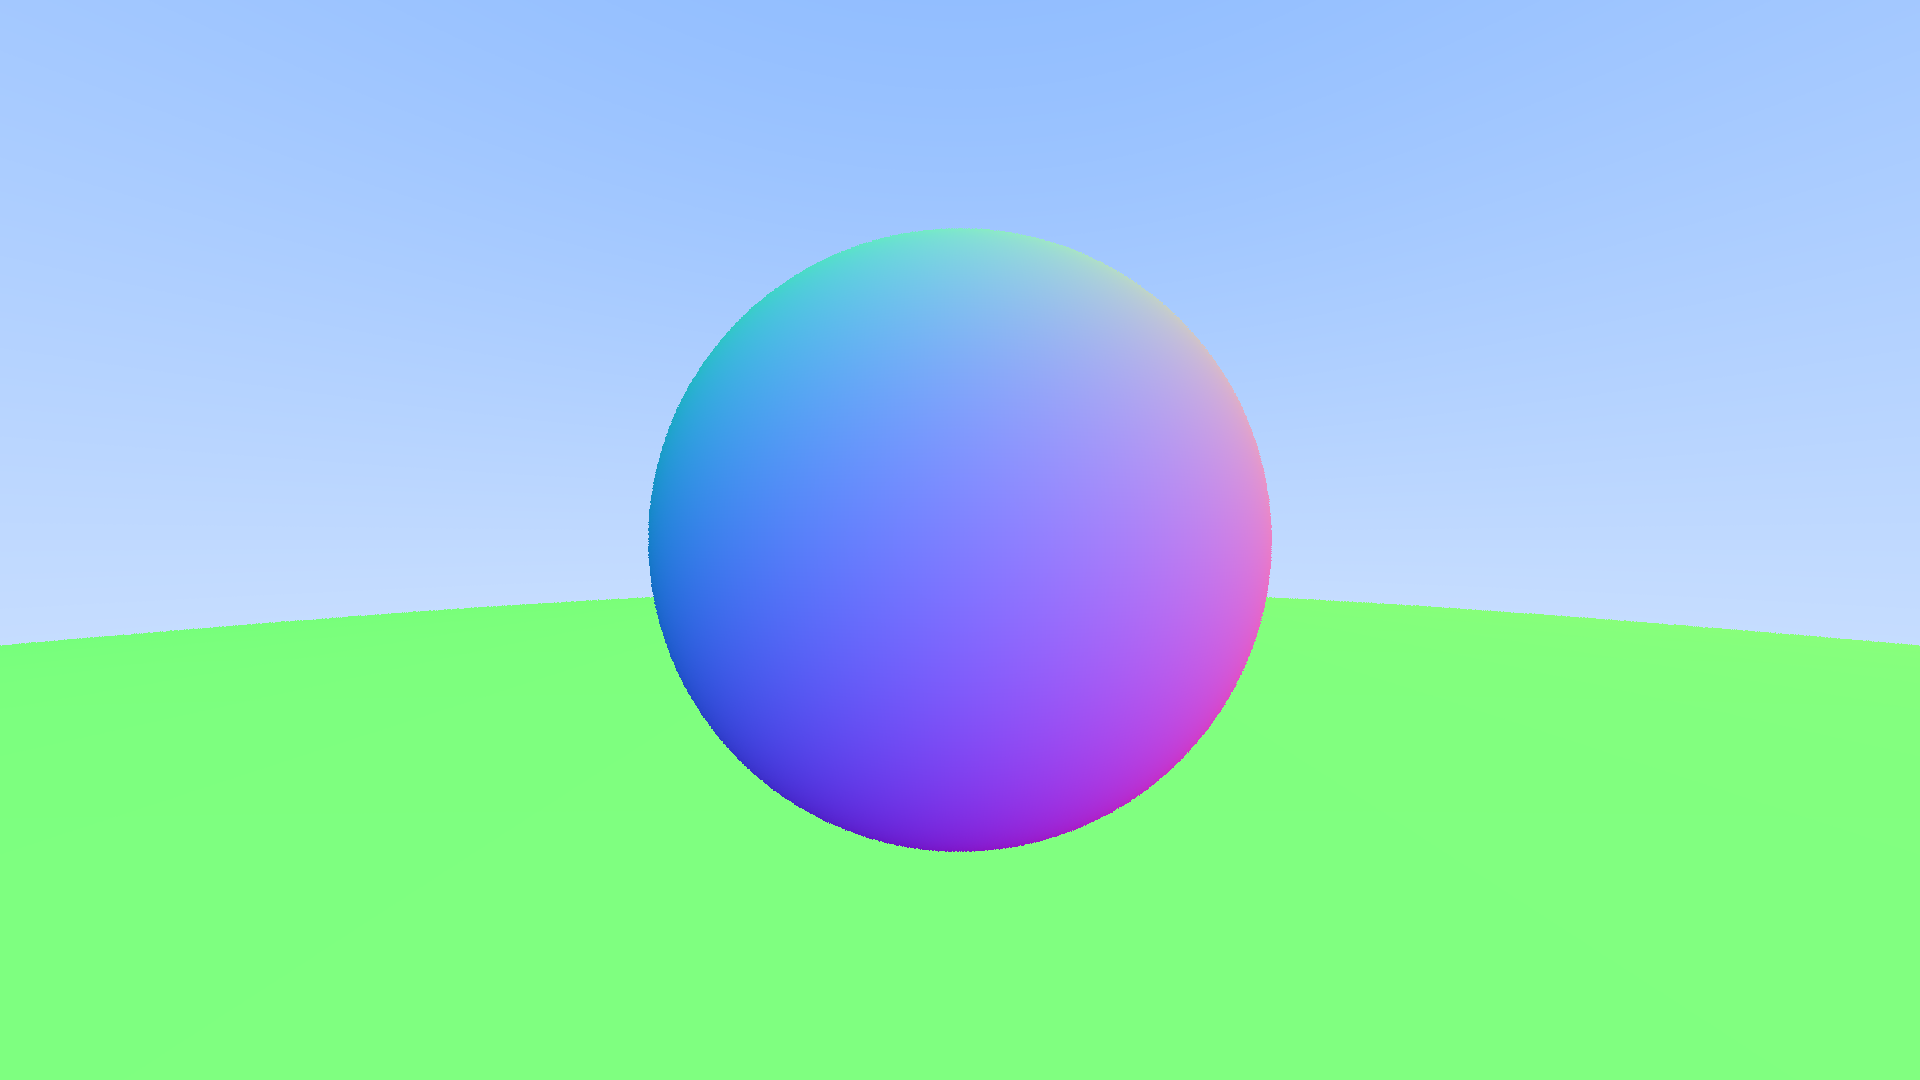

In [18]:
cam.show()

# Code Reduce

In [19]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [22]:
from util.sphere import Sphere
from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 1920//2
cam.samples_per_pixel = 100

cam.render(world)

Rendering: 100%|██████████| 540/540 [09:42<00:00,  1.08s/it]

Done!


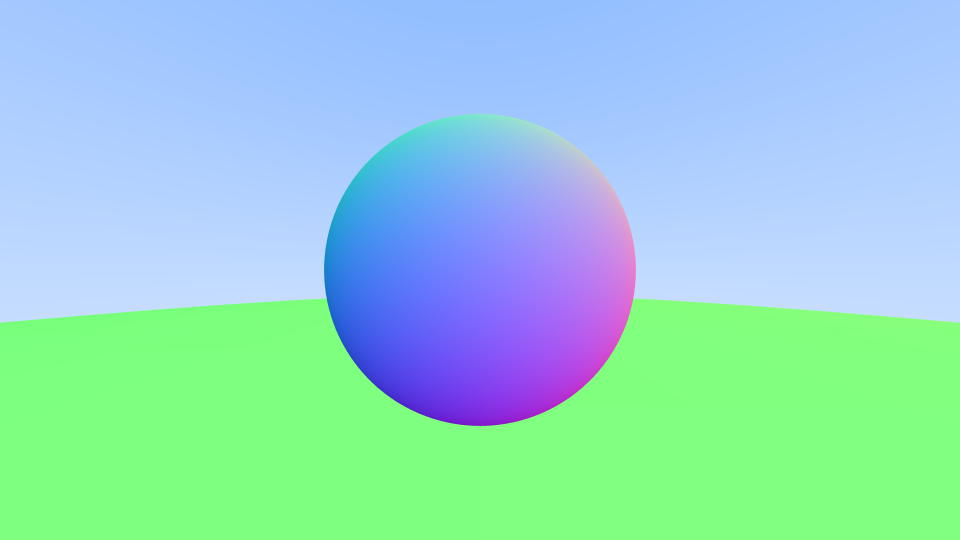

In [23]:
cam.show()